In [1]:
!pip install pandas numpy scikit-learn matplotlib keras tensorflow
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression #for polynomial regression
from sklearn.preprocessing import PolynomialFeatures #for polyonomial regression
from sklearn.neural_network import MLPRegressor #for feedforward neural network regression
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import pyplot as plt
from tensorflow import keras
import tensorflow as tf


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


I0000 00:00:1776199433.109374  100705 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776199433.114962  100705 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776199434.698650  100705 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776199437.580376  100705 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

****1. Loading & exploring the Data set**** + 2. Preparing trainign and validation data

In [2]:
train_data = pd.read_csv('train.csv')
validation_data = pd.read_csv('val.csv')


In [3]:
#identifying features and target variable
X_train = train_data.drop('y', axis=1) #feature for training
y_train = train_data['y'] #target variable for training

X_val = validation_data.drop('y', axis=1) #x feature for validation
y_val = validation_data['y'] #target variable for validation


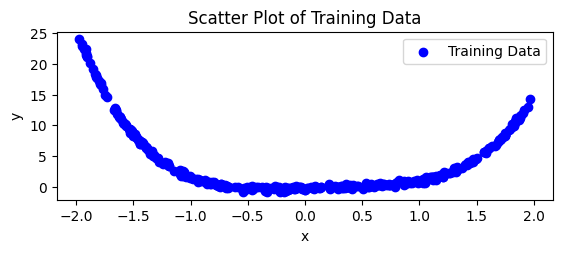

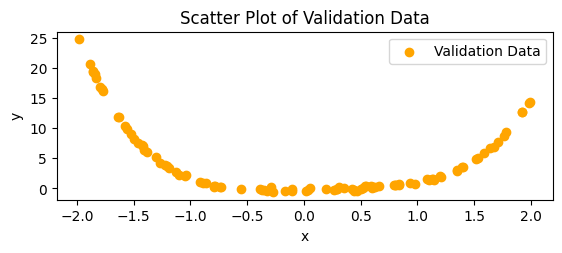

In [4]:
plt.subplot(2,1,2)
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.scatter(X_val, y_val, color='orange', label='Validation Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of Validation Data')
plt.legend()
plt.show()


***Interpretation***
- the data above is plotted for the training and validation set
- the input variable is x and the output variable is y
- It forms a structure similar to a polynomial regression with degree 2

****3. Implementing the baseline least squares****

In [5]:
#polynomial regression
degree = 4 #degree of the polynomial
poly_features = PolynomialFeatures(degree=degree)
X_train_poly_four = poly_features.fit_transform(X_train) #transforming the training data to include
#polynomial features
X_val_poly = poly_features.transform(X_val) #transforming the validation data to include polynomial
#features
poly_model = LinearRegression() #creating a linear regression model
poly_model.fit(X_train_poly_four, y_train) #fitting the model to the training data
y_val_pred_poly = poly_model.predict(X_val_poly) #predicting the target variable for
#validation data
mse_poly = mean_squared_error(y_val, y_val_pred_poly) #calculating mean squared error for polynomial regression
r2_poly = r2_score(y_val, y_val_pred_poly) #calculating R-squared score for polynomial regression
print(f'Polynomial Regression (degree={degree}): MSE={mse_poly}, R2={r2_poly}')
print(f'Polynomial Regression Coefficients: {poly_model.coef_}, Intercept: {poly_model.intercept_}')


Polynomial Regression (degree=4): MSE=0.03073080806923643, R2=0.9991388369981277
Polynomial Regression Coefficients: [ 0.          0.50759346  0.28989804 -0.80366203  1.20539343], Intercept: -0.21463817306569632


****4. Neural network, Tensorflow implementation****

In [13]:
#Model architecture: Keras and tensorflow
model = tf.keras.Sequential()

#layer 1 & 2: input layer with 32 neurons and ReLU activation function
model.add(tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(tf.keras.layers.Dense(32, activation='relu'))
#layer 2: output layer with 1 neuron (for regression) and no activation function
model.add(tf.keras.layers.Dense(1))

model.summary()



/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compling the model
model.compile(optimizer='sgd', loss='mean_squared_error', metrics= [tf.keras.metrics.R2Score()])

#training the model
history_nn = model.fit(X_train, y_train, epochs=300, batch_size=32, validation_data=(X_val, y_val)) #keras does not using validation data for training, it only uses it to evaluate the model after each epoch

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 28.6435 - r2_score: -0.0142 - val_loss: 19.2459 - val_r2_score: 0.4607
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.7339 - r2_score: 0.5137 - val_loss: 14.1093 - val_r2_score: 0.6046
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.1664 - r2_score: 0.6400 - val_loss: 11.8520 - val_r2_score: 0.6679
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.5587 - r2_score: 0.7324 - val_loss: 7.9935 - val_r2_score: 0.7760
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5806 - r2_score: 0.8024 - val_loss: 6.2461 - val_r2_score: 0.8250
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4649 - r2_score: 0.8419 - val_loss: 5.6174 - val_r2_score: 0.8426
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2228 - r2_score: 0.8859 - val_loss: 4.5247 - val_r2_score: 0.8732
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.4013 - r2_score: 0.8796 - val_loss: 4.8223

****4.1 Monitoring training behavior during optimization: Stochastic gradient descent****

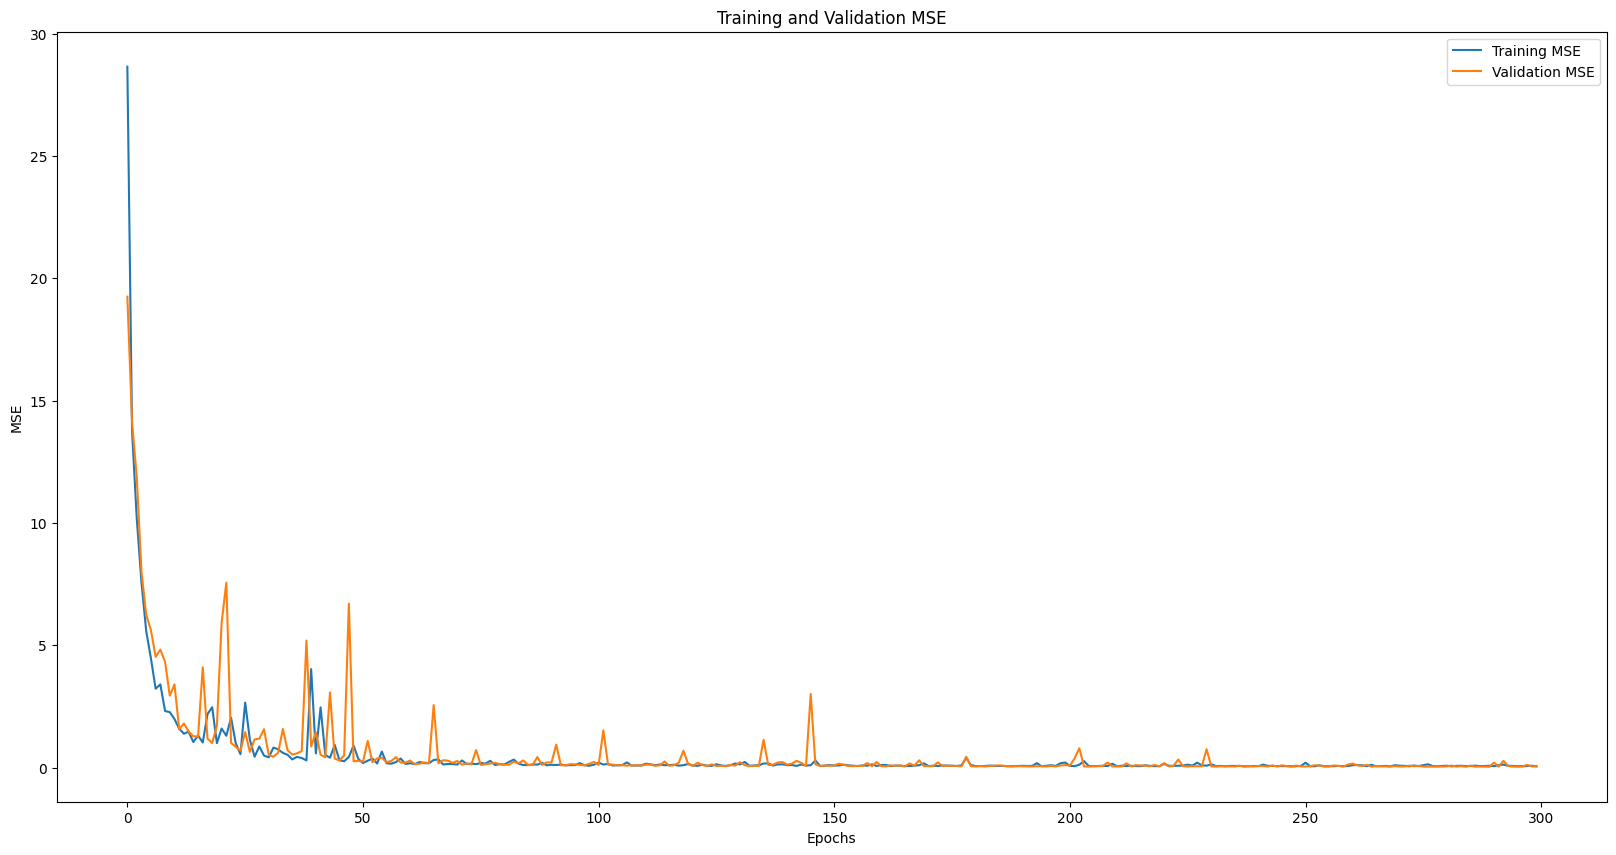

In [ ]:
#retrieve the training history - Loss values for each epoch
train_loss = history_nn.history['loss']
val_loss = history_nn.history['val_loss']

#retrieve the training history - MSE for each epoch
#plotting the training and validation loss
plt.figure(figsize=(20, 10))
plt.plot(train_loss, label='Training MSE')
plt.plot(val_loss, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Training and Validation MSE')
plt.legend()
plt.show()


****5. Evaluating model performance: Polynomial regression vs neural network****

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Neural Network Regression: MSE=0.0474, R2=0.9987


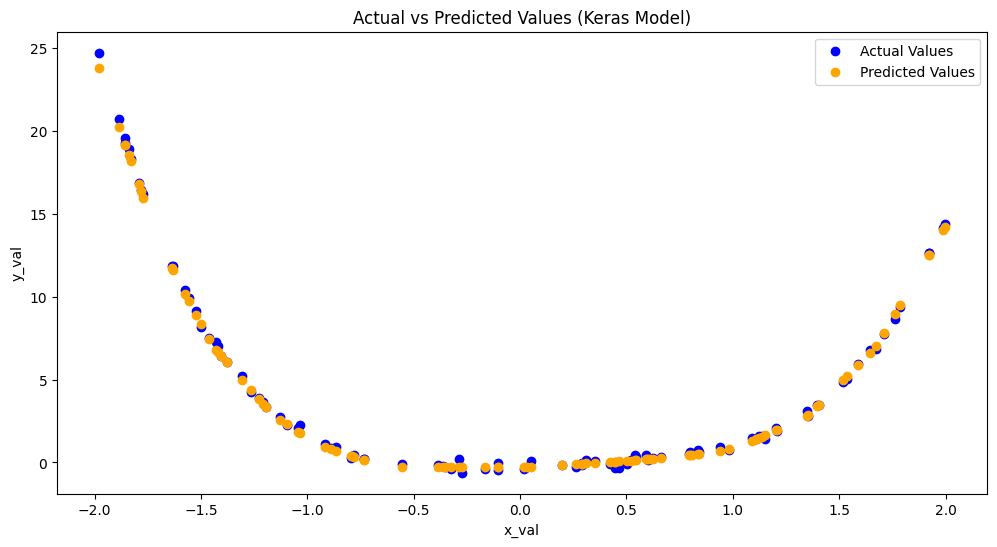

In [9]:
#model predictions on validation data
y_val_pred_keras = model.predict(X_val) 
nn_mse_test = mean_squared_error(y_val, y_val_pred_keras) #computing prediction error for neural network regression
nn_r2_test = r2_score(y_val, y_val_pred_keras) #calculating R-squared score for neural network regression
print(f'Neural Network Regression: MSE={nn_mse_test:.4f}, R2={nn_r2_test:.4f}')
#plotting the predicted vs actual values for validation data - nn mode
plt.figure(figsize=(12, 6))
plt.scatter(X_val, y_val, color='blue', label='Actual Values')
plt.scatter(X_val, y_val_pred_keras, color='orange', label='Predicted Values')
plt.xlabel('x_val')
plt.ylabel('y_val')
plt.title('Actual vs Predicted Values (Keras Model)')
plt.legend()
plt.show()



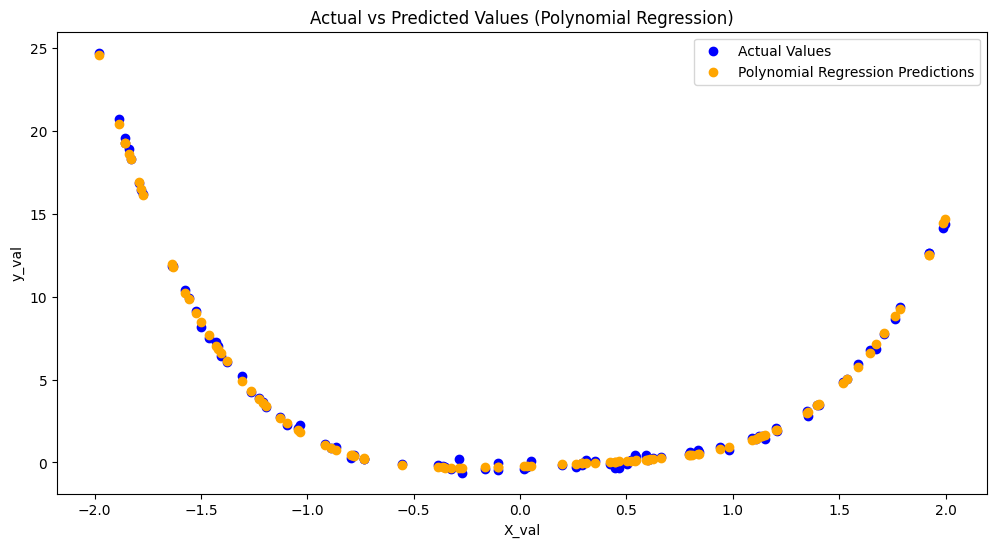

In [10]:
#visualizing the predictions of both models
plt.figure(figsize=(12, 6))
plt.scatter(X_val, y_val, color='blue', label='Actual Values')
plt.scatter(X_val, y_val_pred_poly, color='orange', label='Polynomial Regression Predictions')
plt.title('Actual vs Predicted Values (Polynomial Regression)')
plt.xlabel('X_val')
plt.ylabel('y_val')
plt.legend()
plt.show()

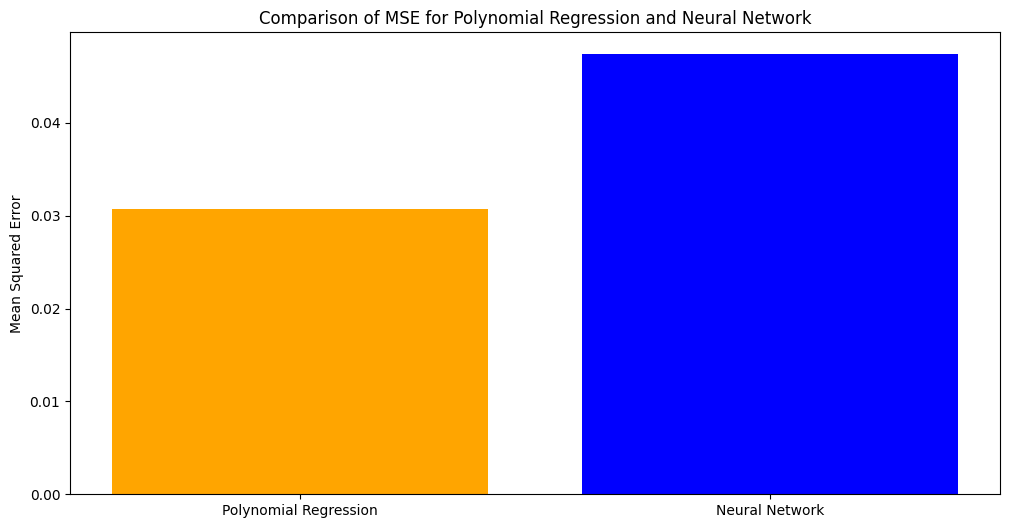

In [11]:
#comparing the metrics of both models
plt.figure(figsize=(12, 6))
plt.bar(['Polynomial Regression', 'Neural Network'], [mse_poly, nn_mse_test], color=['orange', 'blue'])
plt.ylabel('Mean Squared Error')
plt.title('Comparison of MSE for Polynomial Regression and Neural Network')
plt.show()

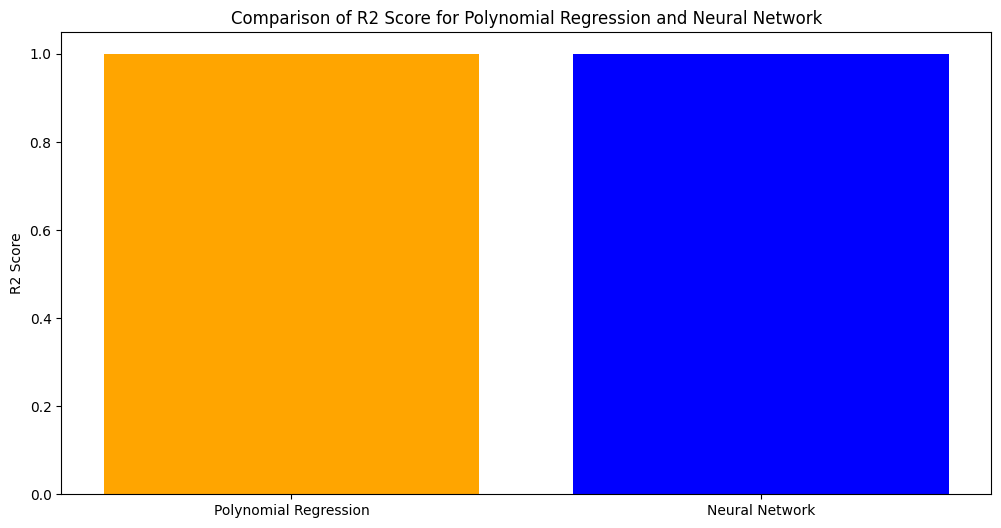

In [12]:
#comparing the metrics r2 score of both models
plt.figure(figsize=(12, 6))
plt.bar(['Polynomial Regression', 'Neural Network'], [r2_poly, nn_r2_test], color=['orange', 'blue'])
plt.ylabel('R2 Score')
plt.title('Comparison of R2 Score for Polynomial Regression and Neural Network')
plt.show()